# Library

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Memanggil Data

In [3]:
data = pd.read_csv(r"D:\Sem 4\PBL\data\raw\Retail-Supply-Chain-Sales.csv")

data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Retail Sales People,Product ID,Category,Sub-Category,Product Name,Returned,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,8/11/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Cassandra Brandow,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,Not,261.96,2,0.00,41.91
1,2,CA-2016-152156,8/11/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Cassandra Brandow,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",Not,731.94,3,0.00,219.58
2,3,CA-2016-138688,12/6/2016,12/6/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Anna Andreadi,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,Not,14.62,2,0.00,6.87
3,4,US-2015-108966,11/10/2015,11/10/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Cassandra Brandow,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,Not,957.58,5,0.45,-383.03
4,5,US-2015-108966,11/10/2015,11/10/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Cassandra Brandow,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,Not,22.37,2,0.20,2.52


# Cek Jumlah Baris dan Kolom Data

In [4]:
print("jumlah baris:", data.shape[0])
print("jumlah kolom:", data.shape[1])

jumlah baris: 9994
jumlah kolom: 23


# Informasi seputar data

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Row ID               9994 non-null   int64  
 1   Order ID             9994 non-null   object 
 2   Order Date           9994 non-null   object 
 3   Ship Date            9994 non-null   object 
 4   Ship Mode            9994 non-null   object 
 5   Customer ID          9994 non-null   object 
 6   Customer Name        9994 non-null   object 
 7   Segment              9994 non-null   object 
 8   Country              9994 non-null   object 
 9   City                 9994 non-null   object 
 10  State                9994 non-null   object 
 11  Postal Code          9994 non-null   int64  
 12  Region               9994 non-null   object 
 13  Retail Sales People  9994 non-null   object 
 14  Product ID           9994 non-null   object 
 15  Category             9994 non-null   o

# Cek Missing Value

In [6]:
data.isnull().sum()

Row ID                 0
Order ID               0
Order Date             0
Ship Date              0
Ship Mode              0
Customer ID            0
Customer Name          0
Segment                0
Country                0
City                   0
State                  0
Postal Code            0
Region                 0
Retail Sales People    0
Product ID             0
Category               0
Sub-Category           0
Product Name           0
Returned               0
Sales                  0
Quantity               0
Discount               0
Profit                 0
dtype: int64

# Cek Data Duplikat

In [7]:
print("Jumlah duplikasi :", data.duplicated().sum())

Jumlah duplikasi : 0


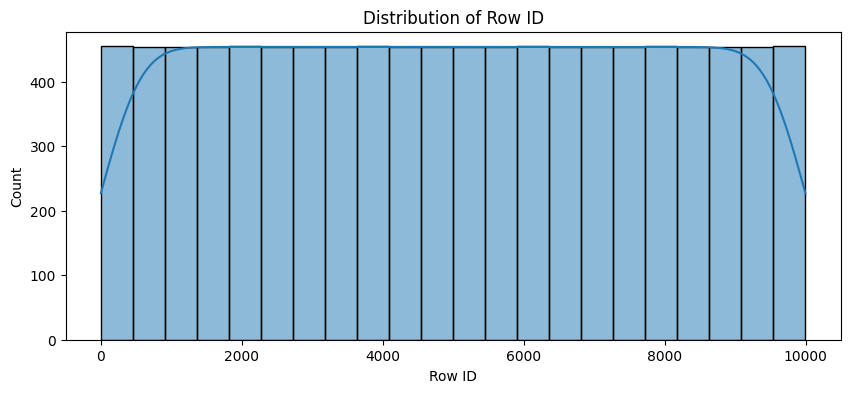

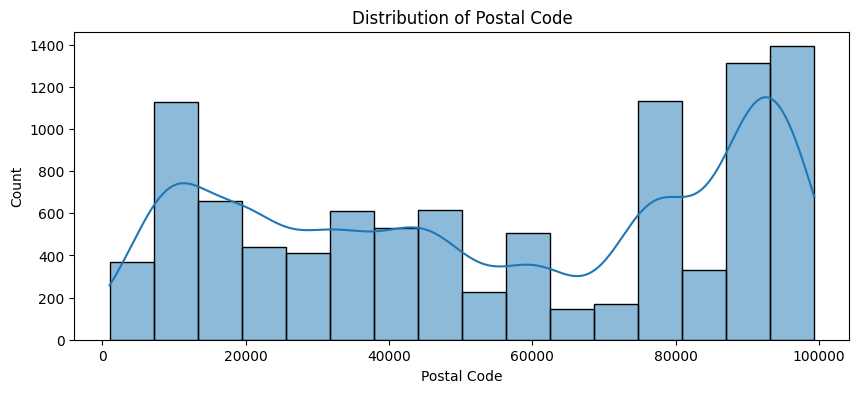

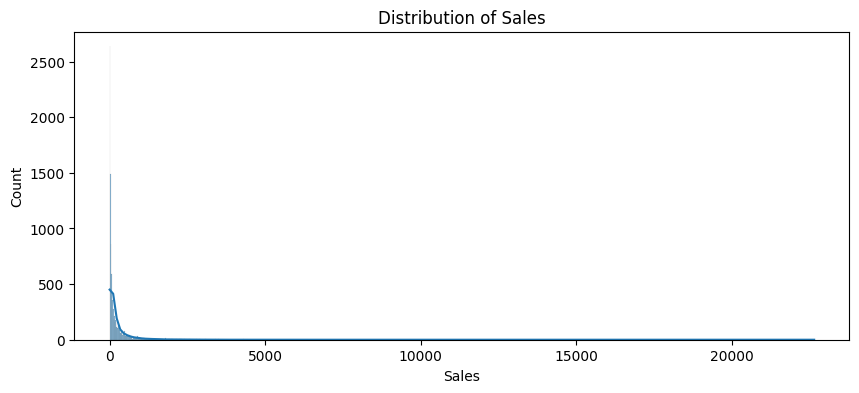

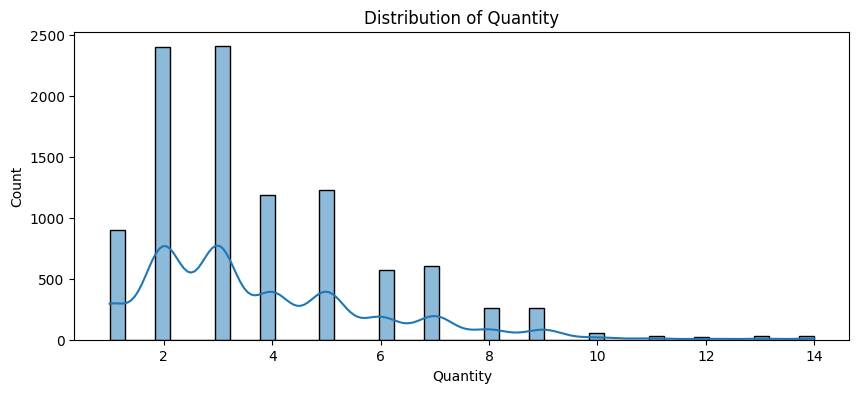

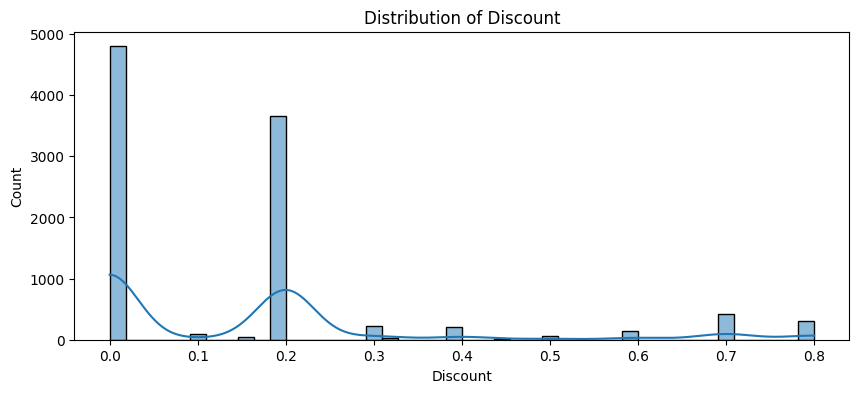

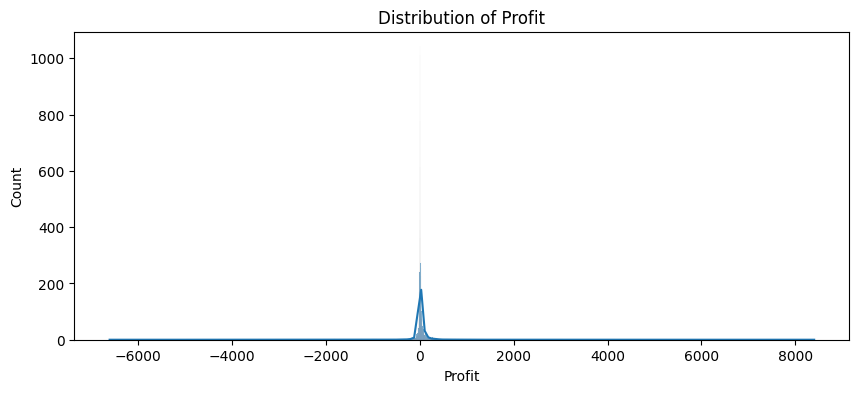

In [8]:
# =========================================================
# DISTRIBUSI NUMERICAL FEATURE
# =========================================================

numerical_cols = data.select_dtypes(include=np.number).columns

for col in numerical_cols:

    plt.figure(figsize=(10,4))

    sns.histplot(
        data[col],
        kde=True
    )

    plt.title(f"Distribution of {col}")

    plt.show()

In [9]:
subcategories = (
    data["Sub-Category"]
    .unique()
)

print("total produk sub kategori :",len(subcategories))

print("\n", subcategories)

total produk sub kategori : 17

 ['Bookcases' 'Chairs' 'Labels' 'Tables' 'Storage' 'Furnishings' 'Art'
 'Phones' 'Binders' 'Appliances' 'Paper' 'Accessories' 'Envelopes'
 'Fasteners' 'Supplies' 'Machines' 'Copiers']


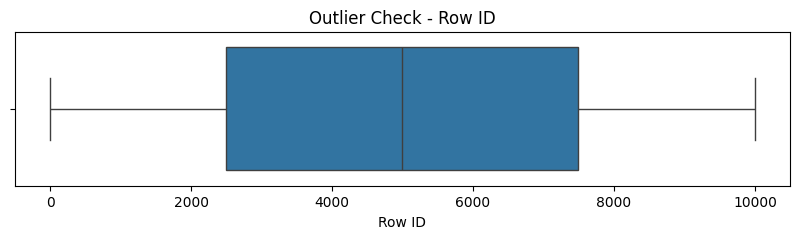

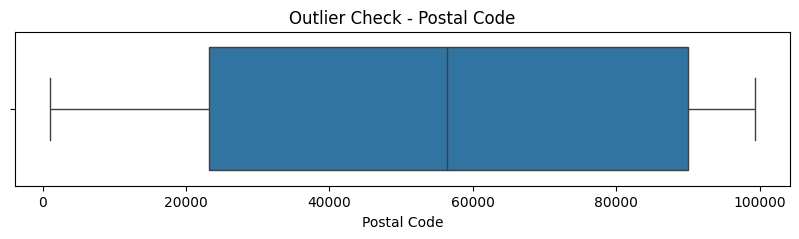

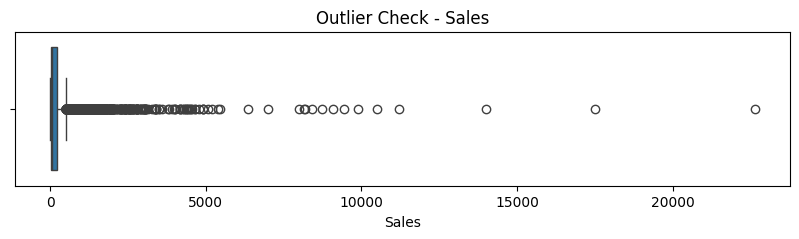

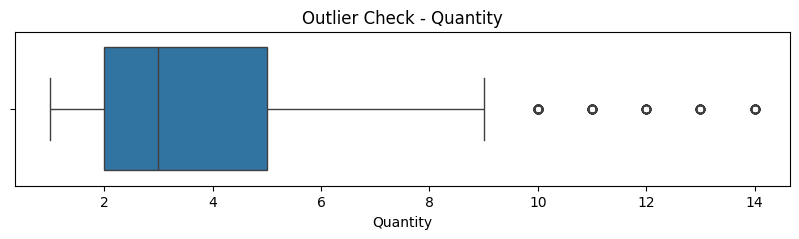

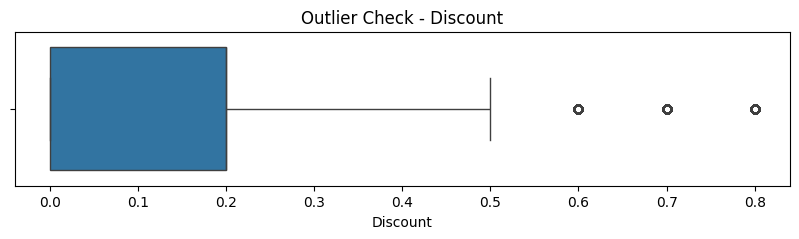

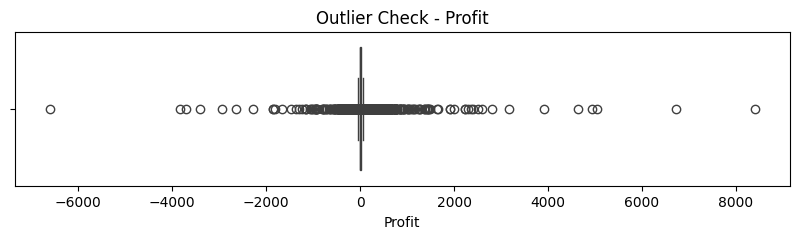

In [10]:
for col in numerical_cols:

    plt.figure(figsize=(10,2))

    sns.boxplot(
        x=data[col]
    )

    plt.title(f"Outlier Check - {col}")

    plt.show()

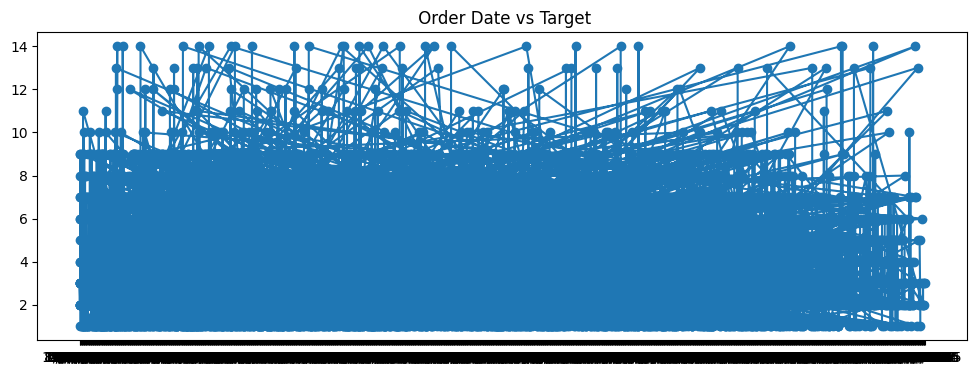

In [11]:
plt.figure(figsize=(12,4))

plt.plot(
        data["Order Date"],
        data["Quantity"],
        marker='o',
    )
plt.title(" Order Date vs Target")

plt.show()

     KORELASI SEMUA FITUR TERHADAP QUANTITY      
Quantity                    1.000000
Sales                       0.200795
Profit                      0.066253
Sub-Category_Fasteners      0.028283
Sub-Category_Binders        0.025336
Ship Mode_Standard Class    0.016580
Segment_Corporate           0.016011
Region_West                 0.012334
Discount                    0.008623
Region_South                0.008528
Sub-Category_Tables         0.008219
Sub-Category_Accessories    0.006571
Category_Office Supplies    0.006436
Ship Mode_Second Class      0.005938
Sub-Category_Labels         0.004944
Returned_Yes                0.003537
Sub-Category_Chairs         0.003332
Sub-Category_Machines       0.001771
Sub-Category_Bookcases      0.001198
Category_Furniture         -0.001065
Segment_Home Office        -0.001505
Sub-Category_Paper         -0.001793
Region_Central             -0.002468
Sub-Category_Art           -0.002741
Returned_Not               -0.003537
Category_Technology      

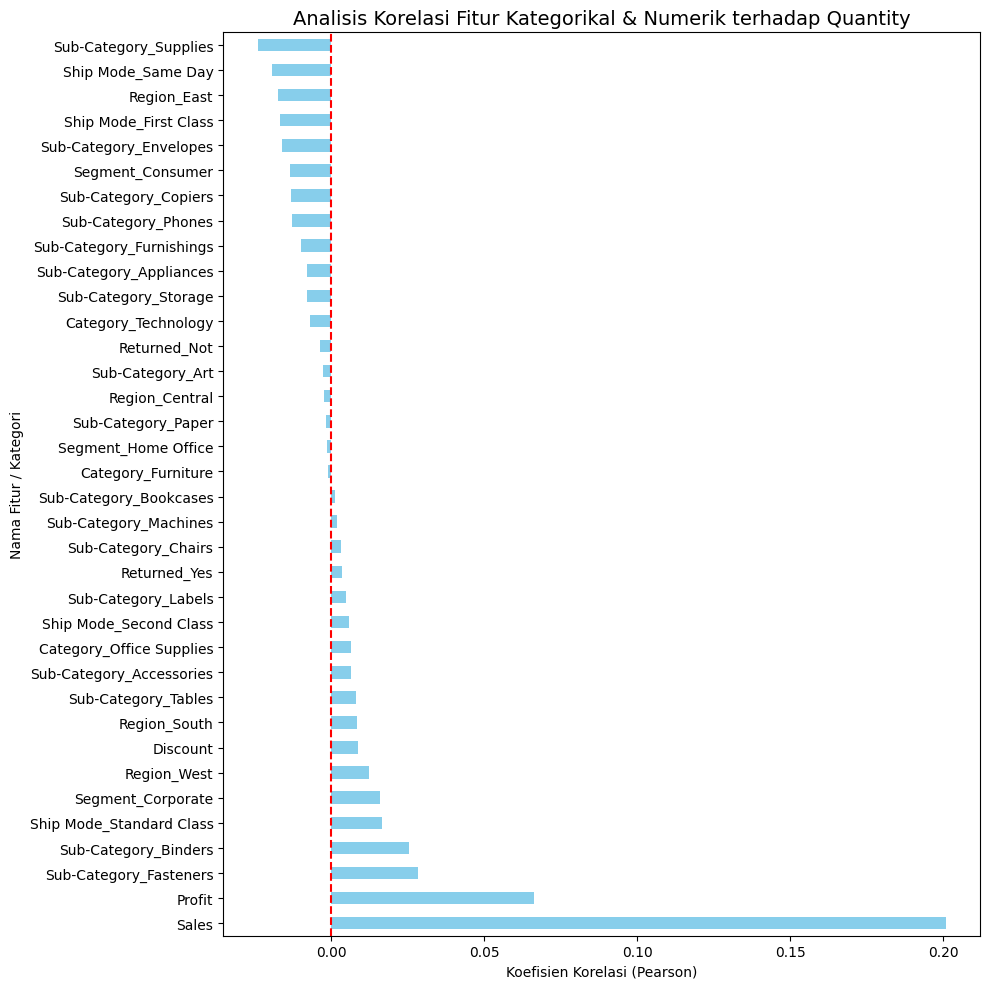

In [12]:

# 2. Pilih kolom numerik dan kolom kategorikal yang penting (Low Cardinality)
# Kolom dengan ribuan nilai unik seperti 'Product Name' kita skip dulu untuk analisis ini
categorical_cols = ['Ship Mode', 'Segment', 'Region', 'Category', 'Sub-Category', 'Returned']
numerical_cols = ['Sales', 'Discount', 'Profit', 'Quantity']

# Gabungkan kolom yang akan dianalisis
df_analysis = data[categorical_cols + numerical_cols].copy()

# 3. Ubah kolom object menjadi angka menggunakan One-Hot Encoding
# Parameter dtype=int mengubah output True/False menjadi angka 1 dan 0
df_encoded = pd.get_dummies(df_analysis, columns=categorical_cols, dtype=int)

# 4. Hitung korelasi khusus terhadap kolom 'Quantity'
corr_with_quantity = df_encoded.corr()['Quantity'].sort_values(ascending=False)

# 5. Tampilkan hasil berupa teks
print("="*60)
print("     KORELASI SEMUA FITUR TERHADAP QUANTITY      ")
print("="*60)
print(corr_with_quantity)
print("="*60)

# 6. VISUALISASI BERUPA BAR PLOT
plt.figure(figsize=(10, 10))
# Drop baris 'Quantity' itu sendiri agar tidak mengacaukan visualisasi (karena nilainya pasti 1.0)
corr_with_quantity.drop('Quantity').plot(kind='barh', color='skyblue')
plt.axvline(x=0, color='red', linestyle='--') # Garis tengah 0
plt.title('Analisis Korelasi Fitur Kategorikal & Numerik terhadap Quantity', fontsize=14)
plt.xlabel('Koefisien Korelasi (Pearson)')
plt.ylabel('Nama Fitur / Kategori')
plt.tight_layout()
plt.show()